# 03 — Predictive Modeling and Evaluation

This notebook develops and evaluates a machine-failure classifier using the prepared AI4I dataset. The workflow focuses on class imbalance, classification-threshold trade-offs, model discrimination, feature importance, and the operational interpretation of predictions for predictive maintenance.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    auc,
    precision_recall_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

RANDOM_STATE = 42

# Creates subfolders figures and tables in the colab environment where individual
# figures and tables are stored during the notebook run. Provides the user with
# the ability to download these and maintains reproducibility of the outputs

TABLES_DIR = Path("/content/outputs/tables")
TABLES_DIR.mkdir(parents=True, exist_ok=True)

FIGURES_DIR = Path("/content/outputs/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


## 1. Load and prepare the modeling data


In [2]:
from pathlib import Path

UCI_DATA_URL = "https://archive.ics.uci.edu/static/public/601/ai4i%2B2020%2Bpredictive%2Bmaintenance%2Bdataset.zip"

# Resolve the repository root when running locally. In a fresh Colab runtime,
# no repository data folder exists, so the notebook falls back to UCI.
def find_repo_root():
    cwd = Path.cwd()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate
    return cwd

REPO_ROOT = find_repo_root()
LOCAL_DATA_PATH = REPO_ROOT / "data" / "raw" / "ai4i2020.csv"

if LOCAL_DATA_PATH.exists():
    df = pd.read_csv(LOCAL_DATA_PATH)
else:
    df = pd.read_csv(UCI_DATA_URL, compression="zip")


In [3]:
df = df.rename(
    columns={
        "UDI": "udi",
        "Product ID": "product_id",
        "Type": "type",
        "Air temperature [K]": "air_temperature_k",
        "Process temperature [K]": "process_temperature_k",
        "Rotational speed [rpm]": "rotational_speed_rpm",
        "Torque [Nm]": "torque_nm",
        "Tool wear [min]": "tool_wear_min",
        "Machine failure": "machine_failure",
        "TWF": "twf",
        "HDF": "hdf",
        "PWF": "pwf",
        "OSF": "osf",
        "RNF": "rnf",
    }
)


In [4]:
# Temperature difference between the process and surrounding air
df["temperature_difference_k"] = (
    df["process_temperature_k"] - df["air_temperature_k"]
)

# Mechanical rotational power: P = torque × angular velocity
df["mechanical_power_kw"] = (
    df["torque_nm"]
    * df["rotational_speed_rpm"]
    * 2
    * np.pi
    / 60
    / 1000
)


In [5]:
numeric_features = [
    "air_temperature_k",
    "process_temperature_k",
    "rotational_speed_rpm",
    "torque_nm",
    "tool_wear_min",
    "temperature_difference_k",
    "mechanical_power_kw",
]

categorical_features = ["type"]
feature_cols = numeric_features + categorical_features

X = df[feature_cols].copy()
y = df["machine_failure"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget:")
print(y.value_counts())


X shape: (10000, 8)
y shape: (10000,)

Target:
machine_failure
0    9661
1     339
Name: count, dtype: int64


Failures account for only 3.39% of observations, so the target is strongly imbalanced. A stratified split is therefore used to preserve approximately the same failure prevalence in the training and test sets.


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)


In [7]:
print("Training observations:", len(y_train))
print("Test observations:", len(y_test))

print("\nTraining target distribution (%):")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTest target distribution (%):")
print(y_test.value_counts(normalize=True).mul(100).round(2))


Training observations: 8000
Test observations: 2000

Training target distribution (%):
machine_failure
0    96.61
1     3.39
Name: proportion, dtype: float64

Test target distribution (%):
machine_failure
0    96.6
1     3.4
Name: proportion, dtype: float64


The 2,000-row test set contains 68 actual failures. Because failures are rare, accuracy alone would be misleading. Therefore recall, precision, F1-score, ranking metrics, and the confusion matrix are more informative for this use case.


## 2. Preprocessing

The numerical features are passed through unchanged because Random Forest does not require feature scaling. The categorical product-type feature is one-hot encoded, with unseen categories ignored during prediction.


In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features,
        )
    ],
    remainder="passthrough",
)


## 3. Naive baseline


In [9]:
baseline_predictions = np.zeros(len(y_test), dtype=int)

baseline_accuracy = accuracy_score(y_test, baseline_predictions)
baseline_precision = precision_score(
    y_test, baseline_predictions, zero_division=0
)
baseline_recall = recall_score(
    y_test, baseline_predictions, zero_division=0
)
baseline_f1 = f1_score(
    y_test, baseline_predictions, zero_division=0
)

print(f"Baseline Accuracy: {baseline_accuracy:.2f}")
print(f"Baseline Precision: {baseline_precision:.2f}")
print(f"Baseline Recall: {baseline_recall:.2f}")
print(f"Baseline F1 Score: {baseline_f1:.2f}")


Baseline Accuracy: 0.97
Baseline Precision: 0.00
Baseline Recall: 0.00
Baseline F1 Score: 0.00


The all-negative baseline reaches 96.6% accuracy while detecting no failures. This confirms that high accuracy can be almost meaningless on this imbalanced target and provides a useful benchmark for the trained classifier.


## 4. Class-weighted Random Forest

A Random Forest is trained with `class_weight="balanced"` so errors on the minority failure class receive greater weight during training. This is evaluated before introducing more complex imbalance treatments such as synthetic oversampling.


In [10]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", rf_model),
    ]
)


In [11]:
rf_pipeline.fit(X_train, y_train);


In [12]:
y_pred = rf_pipeline.predict(X_test)
y_prob = rf_pipeline.predict_proba(X_test)[:, 1]


In [13]:
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred):.3f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.3f}")


Accuracy:  0.988
Precision: 0.940
Recall:    0.691
F1-score:  0.797
ROC-AUC:   0.966


At the classifier's default prediction rule, failure-class precision is very high (0.940), but recall is lower (0.691). For predictive maintenance, missed failures may be substantially more costly than unnecessary inspections, so the next step is to examine whether a lower classification threshold can improve recall without sacrificing too much precision.


## 5. Classification-threshold sensitivity


In [14]:
thresholds = [0.50, 0.40, 0.30, 0.20]
threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred_threshold,
    ).ravel()

    threshold_results.append(
        {
            "threshold": threshold,
            "precision": precision_score(
                y_test, y_pred_threshold, zero_division=0
            ),
            "recall": recall_score(
                y_test, y_pred_threshold, zero_division=0
            ),
            "f1_score": f1_score(
                y_test, y_pred_threshold, zero_division=0
            ),
            "false_positives": fp,
            "false_negatives": fn,
            "true_positives": tp,
        }
    )


metrics_at_thresholds = pd.DataFrame(threshold_results)
metrics_at_thresholds.round(3)

metrics_at_thresholds.round(3).to_csv(
    TABLES_DIR / "threshold_metrics.csv",
    index=False
)


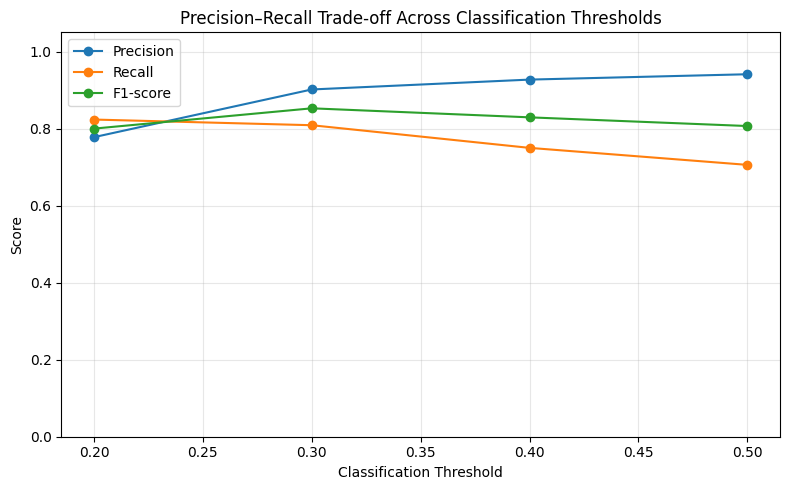

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    metrics_at_thresholds["threshold"],
    metrics_at_thresholds["precision"],
    marker="o",
    label="Precision",
)
plt.plot(
    metrics_at_thresholds["threshold"],
    metrics_at_thresholds["recall"],
    marker="o",
    label="Recall",
)
plt.plot(
    metrics_at_thresholds["threshold"],
    metrics_at_thresholds["f1_score"],
    marker="o",
    label="F1-score",
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision–Recall Trade-off Across Classification Thresholds")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()


plt.savefig(
    FIGURES_DIR / "threshold_tradeoff.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


Lowering the threshold increases the number of failure alerts and improves recall, but also creates more false positives. Among the tested values, 0.30 provides the strongest balance: recall increases to 0.809, precision remains high at 0.902, and F1-score reaches 0.853. Moving from 0.30 to 0.20 captures only one additional failure while adding ten false positives.

For this exploratory analysis, 0.30 is therefore selected as the operating threshold. In a production workflow, threshold selection should be performed on validation data or through cross-validation, with final performance reported on a separate untouched test set.

**Implementation note:** the explicit 0.50 row above uses `y_prob >= 0.50`. One observation has a predicted probability exactly equal to 0.50, so it is classified as failure by the explicit rule but as non-failure by `RandomForestClassifier.predict()`, which resolves the tie to class 0. This accounts for the one-observation difference from the default prediction metrics.


## 6. Evaluation at the selected threshold


In [16]:
selected_threshold = 0.30
y_pred_selected = (y_prob >= selected_threshold).astype(int)


In [17]:
selected_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_selected),
    "precision": precision_score(y_test, y_pred_selected),
    "recall": recall_score(y_test, y_pred_selected),
    "f1_score": f1_score(y_test, y_pred_selected),
    "roc_auc": roc_auc_score(y_test, y_prob),
}

pd.Series(selected_metrics).round(3)


,0
accuracy,0.990
precision,0.902
recall,0.809
f1_score,0.853
roc_auc,0.966


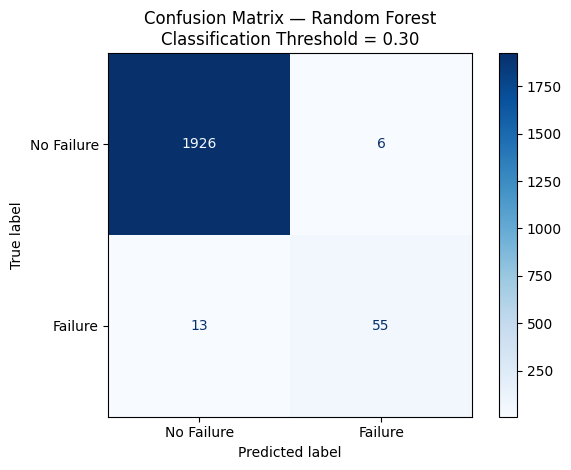

In [18]:
cm = confusion_matrix(y_test, y_pred_selected)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Failure", "Failure"],
)

disp.plot(cmap="Blues", values_format="d")
plt.title(
    "Confusion Matrix — Random Forest\n"
    "Classification Threshold = 0.30"
)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "confusion_matrix_threshold_030.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


At the 0.30 threshold, the model identifies 55 of 68 actual failures (80.9% recall), misses 13 failures, and generates 6 false alerts among 1,932 non-failure observations. This illustrates the operational trade-off of accepting a small increase in unnecessary inspections in exchange for detecting more potential failures.


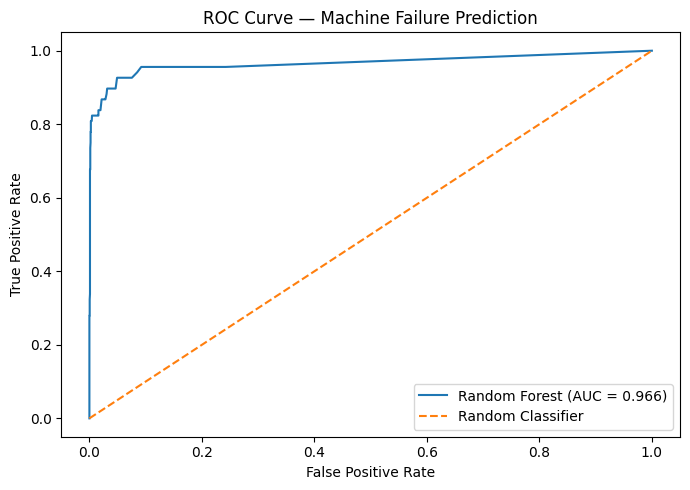

In [19]:
fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {roc_auc:.3f})",
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier",
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Machine Failure Prediction")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


The ROC-AUC of 0.966 indicates strong discrimination across classification thresholds: the model generally assigns higher failure scores to actual failures than to non-failures. ROC-AUC is threshold-independent, so it describes ranking quality rather than the suitability of the selected 0.30 operating threshold. Because the target is highly imbalanced, the Precision–Recall curve provides an important complementary view.


In [20]:
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(
    y_test,
    y_prob,
)

average_precision = average_precision_score(y_test, y_prob)


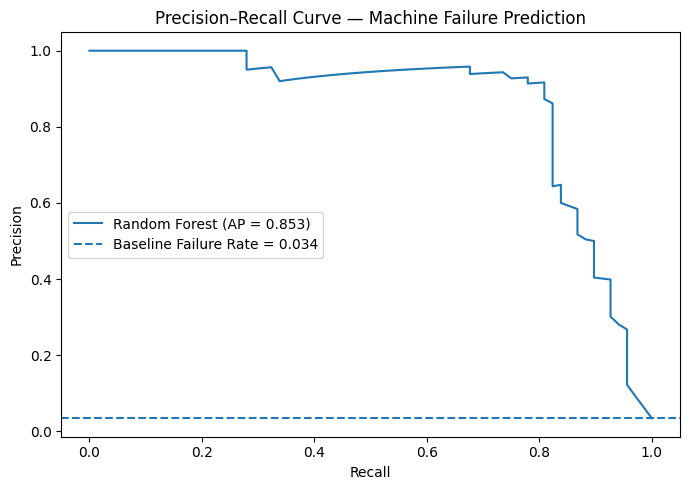

In [21]:
plt.figure(figsize=(7, 5))

plt.plot(
    recall_curve,
    precision_curve,
    label=f"Random Forest (AP = {average_precision:.3f})",
)

baseline_rate = y_test.mean()
plt.axhline(
    y=baseline_rate,
    linestyle="--",
    label=f"Baseline Failure Rate = {baseline_rate:.3f}",
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve — Machine Failure Prediction")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "precision_recall_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


With failures representing only about 3.4% of observations, the Precision–Recall curve is especially informative. The model achieves an Average Precision of 0.853, far above the baseline failure prevalence. It maintains high precision across a substantial recall range, although precision declines as the threshold is lowered to pursue very high recall.


In [22]:
model_metrics = pd.DataFrame(
    [{
        "threshold": selected_threshold,
        "accuracy": selected_metrics["accuracy"],
        "precision": selected_metrics["precision"],
        "recall": selected_metrics["recall"],
        "f1_score": selected_metrics["f1_score"],
        "roc_auc": selected_metrics["roc_auc"],
        "average_precision": average_precision,
    }]
)

model_metrics.round(3).to_csv(
    TABLES_DIR / "model_metrics.csv",
    index=False
)

model_metrics.round(3)

,threshold,accuracy,precision,recall,f1_score,roc_auc,average_precision
0,0.3,0.99,0.902,0.809,0.853,0.966,0.853


## 7. Feature importance


In [23]:
feature_names = (
    rf_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)


In [24]:
importances = (
    rf_pipeline
    .named_steps["classifier"]
    .feature_importances_
)

feature_importance = pd.DataFrame(
    {
        "feature": feature_names,
        "importance": importances,
    }
)

feature_importance = (
    feature_importance
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance



,feature,importance
0,remainder__tool_wear_min,0.206668
1,remainder__rotational_speed_rpm,0.205968
2,remainder__torque_nm,0.204512
3,remainder__mechanical_power_kw,0.191332
4,remainder__temperature_difference_k,0.094036
5,remainder__air_temperature_k,0.048253
6,remainder__process_temperature_k,0.034429
7,categorical__type_L,0.006596
8,categorical__type_M,0.005264
9,categorical__type_H,0.002943


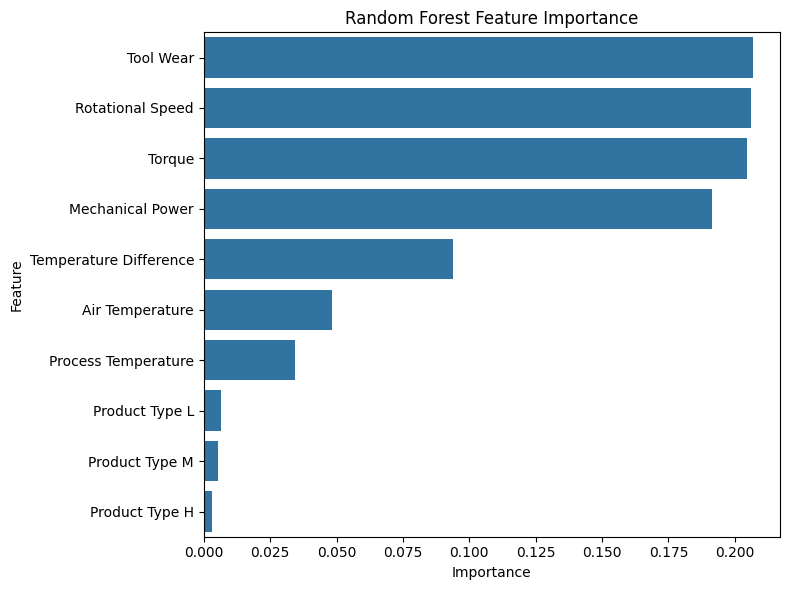

In [25]:
display_names = {
    "remainder__tool_wear_min": "Tool Wear",
    "remainder__rotational_speed_rpm": "Rotational Speed",
    "remainder__torque_nm": "Torque",
    "remainder__mechanical_power_kw": "Mechanical Power",
    "remainder__temperature_difference_k": "Temperature Difference",
    "remainder__air_temperature_k": "Air Temperature",
    "remainder__process_temperature_k": "Process Temperature",
    "categorical__type_L": "Product Type L",
    "categorical__type_M": "Product Type M",
    "categorical__type_H": "Product Type H",
}

feature_importance["display_feature"] = (
    feature_importance["feature"].map(display_names)
)

plt.figure(figsize=(8, 6))
sns.barplot(
    data=feature_importance,
    x="importance",
    y="display_feature",
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [26]:
feature_importance[
    ["feature", "display_feature", "importance"]
].round(6).to_csv(
    TABLES_DIR / "feature_importance.csv",
    index=False
)


Tool wear, rotational speed, torque, and engineered mechanical power receive the highest impurity-based importance scores. This is consistent with the EDA, but these values should not be interpreted as causal effects or independent contributions. Mechanical power is derived directly from torque and rotational speed, so importance could be shared across these correlated predictors.

Outside this mechanical operating-regime group, tool wear and temperature difference emerge as important complementary signals. The engineered temperature difference is more informative than either raw temperature variable alone, suggesting that the relative thermal condition contains useful predictive information. Product-type indicators contribute comparatively little additional information once operating conditions are included.


## 8. Business interpretation and recommendations

At the exploratory 0.30 classification threshold, the model detected 55 of 68 actual failures (80.9% recall) while generating only 6 false failure alerts. From a maintenance perspective, predictions should not necessarily be interpreted as instructions to immediately repair or remove equipment from service. Instead, a high predicted failure risk could be used as an early-warning signal that triggers inspection, diagnostic checks or closer monitoring.

Compared with an explicit 0.50 threshold, lowering the operating threshold to 0.30 detected seven additional failures while generating three additional false alerts. In an equipment-intensive environment where an unexpected breakdown may cause downtime, repair costs and project disruption, this may represent an attractive trade-off. However, the appropriate threshold should ultimately be determined using actual organizational costs associated with missed failures and unnecessary inspections.

Model interpretation suggests that tool wear and the mechanical operating regime represented by rotational speed, torque and mechanical power contribute strongly to predicting failure. These three mechanical-regime variables contain overlapping information, particularly because mechanical power is derived from torque and rotational speed. Temperature difference also provides a complementary thermal signal. In a real predictive-maintenance environment, such telemetry measurements could therefore be monitored continuously to identify equipment operating under conditions associated with higher failure risk.


## 9. Limitations and next steps

AI4I is a synthetic industrial predictive-maintenance dataset. It is not actual construction-equipment telemetry. This means that this project demonstrates a transferable methodology rather than proving performance on excavators, cranes, loaders or other construction equipment.

Real machinery would also have additional variables such as machine age, maintenance history, operating hours, equipment model, operator behaviour, environmental conditions, load cycles and previous faults. These variables could provide additional predictive information, but evaluating their contribution is outside the scope of this project.

Furthermore, thresholds were explored on the held-out test set. In a production workflow, threshold selection should occur using validation data/cross-validation, followed by final evaluation on an untouched test set.

Finally, the model's strong performance should be interpreted partly in the context of the AI4I dataset's simulated structure. The metrics achieved here, such as 80.9% recall and 90.2% precision at the exploratory 0.30 threshold, should therefore not be assumed to transfer directly to real machinery or construction equipment.

Before deployment in a real equipment fleet, the workflow should be retrained and validated using historical equipment telemetry and maintenance records from the target machinery. Additional predictors such as equipment age, operating hours, maintenance history, machine model and environmental/load conditions should be incorporated if and when available.

Classification thresholds should then be selected according to the actual economic and operational costs of missed failures and unnecessary inspections. Model performance and data distributions should also be monitored after deployment because equipment behaviour may change over time.

A further extension of this project would be to move beyond binary machine-failure prediction and model the specific failure modes recorded in the dataset (TWF, HDF, PWF, OSF, and RNF). Because these indicators are defined independently and may overlap, this would be better framed as a multi-label classification problem rather than a strictly multiclass task. Mode-specific models could also reveal predictive relationships that remain hidden to some extent when all failures are aggregated into a single target; for example, product type may become more informative for overstrain failures, while mechanical power may be particularly informative for power failures and thermal conditions for heat-dissipation failures. Such an analysis could provide a stronger diagnostic maintenance signal, although the very small number of observations for some failure modes would limit reliable model evaluation.


## 10. Conclusion

This project demonstrates an end-to-end predictive-maintenance workflow using synthetic industrial machine data to illustrate a methodology that could be adapted to equipment-intensive applications. A class-weighted Random Forest successfully distinguished failure from non-failure observations, with an ROC-AUC of 0.966 and Average Precision of 0.853.

An exploratory operating threshold of 0.30 identified 55 of 68 failures while generating 6 false alerts, showing how classification thresholds can be adapted to maintenance priorities rather than selected only from statistical performance. The results suggest that operating conditions and wear information can support proactive maintenance decisions, while deployment on real construction equipment would require machine-specific telemetry, historical maintenance records, independent validation and cost-based threshold selection.

A natural next step would be to extend this binary analysis to multi-label failure-mode prediction, examining whether predictors such as product type, mechanical power, and thermal conditions provide stronger diagnostic value for specific failure mechanisms.
